### PROTON THERAPY REGRESSION SCHEDULING MODEL ###

In [1]:
# importing all libraries:

import random as rd
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [2]:
#Reading the dataset
proton_dataset = pd.read_csv("Workload_UFHPTI2.csv")
proton_dataset.head(10)

,Date,Sessions,TxHours_subDelay,AvgFieldsPerPt,AvgLayersPerPt,AvgNumSpotsPerPt,Anesthesia,CSI,CSI or Anesthesia,BID,...,Thorax,Abdomen,CNS,Pelvis,Other,Spine,Month,Quarter,Year,Pacemaker
0,1/7/2020 0:00,17,8.532933,2.529412,19.019608,2347.009804,0,0,0,0,...,0,0,5,1,0,0,1,1,2020,0
1,1/13/2020 0:00,21,10.699600,2.619048,20.785714,2434.095238,0,0,0,0,...,0,0,6,1,0,0,1,1,2020,0
2,1/14/2020 0:00,21,9.649600,2.571429,20.357143,2280.626984,0,0,0,0,...,0,0,6,1,0,0,1,1,2020,0
3,1/15/2020 0:00,18,8.549600,2.555556,20.333333,2382.629630,0,0,0,0,...,0,0,5,1,0,0,1,1,2020,0
4,1/17/2020 0:00,17,8.166267,2.470588,20.568627,2323.147059,0,0,0,0,...,0,0,4,1,0,0,1,1,2020,0
5,1/21/2020 0:00,16,9.016267,2.562500,20.911458,2698.265625,1,1,2,0,...,0,0,4,1,0,0,1,1,2020,0
6,1/22/2020 0:00,15,8.532933,2.533333,20.427778,2765.494444,0,1,1,0,...,0,0,4,0,0,0,1,1,2020,0
7,1/23/2020 0:00,16,9.032933,2.562500,20.713542,2740.734375,1,1,2,0,...,0,0,4,0,0,0,1,1,2020,0
8,1/27/2020 0:00,18,8.816267,2.555556,20.291667,2660.523148,2,1,3,0,...,0,0,4,1,0,0,1,1,2020,0
9,1/28/2020 0:00,20,10.216267,2.600000,21.587500,2676.395833,2,1,3,0,...,0,0,4,1,0,0,1,1,2020,0


In [3]:
# Checking for Missing Values:
proton_dataset.isnull().sum()

Date                 0
Sessions             0
TxHours_subDelay     0
AvgFieldsPerPt       0
AvgLayersPerPt       0
AvgNumSpotsPerPt     0
Anesthesia           0
CSI                  0
CSI or Anesthesia    0
BID                  0
TID                  0
Pediatric            0
HN                   0
Prostate             0
Brain                0
Breast               0
Bone                 0
Thorax               0
Abdomen              0
CNS                  0
Pelvis               0
Other                0
Spine                0
Month                0
Quarter              0
Year                 0
Pacemaker            0
dtype: int64

In [4]:
# Dropping non-numeric column (dates)
df_proton = proton_dataset.drop(columns=["Date"])

# Correlation Matrix to see Relationship between Variables:
corr_matrix = df_proton.corr()
corr_matrix

,Sessions,TxHours_subDelay,AvgFieldsPerPt,AvgLayersPerPt,AvgNumSpotsPerPt,Anesthesia,CSI,CSI or Anesthesia,BID,TID,...,Thorax,Abdomen,CNS,Pelvis,Other,Spine,Month,Quarter,Year,Pacemaker
Sessions,1.000000,0.820024,-0.395691,-0.015057,0.448314,0.105830,0.136753,0.114507,-0.054364,NaN,...,0.064917,-0.045797,0.043823,0.121547,0.047968,NaN,0.006206,0.011664,0.296029,NaN
TxHours_subDelay,0.820024,1.000000,-0.076151,-0.008990,0.225318,0.230346,0.296302,0.293698,0.029706,NaN,...,0.150433,0.088832,0.261547,0.110802,0.099625,NaN,-0.053092,-0.051256,0.143244,NaN
AvgFieldsPerPt,-0.395691,-0.076151,1.000000,0.106497,-0.430168,0.222335,0.301681,0.338501,-0.015260,NaN,...,0.177006,0.217686,0.353438,-0.209531,0.180980,NaN,-0.189541,-0.185961,0.007261,NaN
AvgLayersPerPt,-0.015057,-0.008990,0.106497,1.000000,0.414264,-0.232364,-0.150272,-0.247247,0.192322,NaN,...,-0.079420,-0.111489,-0.389140,-0.057613,-0.001211,NaN,-0.005318,-0.030047,-0.147686,NaN
AvgNumSpotsPerPt,0.448314,0.225318,-0.430168,0.414264,1.000000,0.108797,0.067570,0.099378,-0.066609,NaN,...,-0.063582,-0.030034,-0.324768,0.107430,0.008462,NaN,0.195338,0.186336,0.397779,NaN
Anesthesia,0.105830,0.230346,0.222335,-0.232364,0.108797,1.000000,0.203563,0.888100,-0.272993,NaN,...,0.082410,0.261001,0.258088,-0.036601,0.156837,NaN,0.114373,0.116003,0.594111,NaN
CSI,0.136753,0.296302,0.301681,-0.150272,0.067570,0.203563,1.000000,0.580485,-0.158012,NaN,...,0.215992,0.168343,0.537904,-0.120730,-0.004686,NaN,0.056411,0.065901,0.120673,NaN
CSI or Anesthesia,0.114507,0.293698,0.338501,-0.247247,0.099378,0.888100,0.580485,1.000000,-0.283813,NaN,...,0.168497,0.312097,0.445995,-0.069939,0.135184,NaN,0.120615,0.122300,0.558864,NaN
BID,-0.054364,0.029706,-0.015260,0.192322,-0.066609,-0.272993,-0.158012,-0.283813,1.000000,NaN,...,-0.134717,-0.022661,0.027266,0.093930,-0.154122,NaN,0.035535,0.025988,-0.403178,NaN
TID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


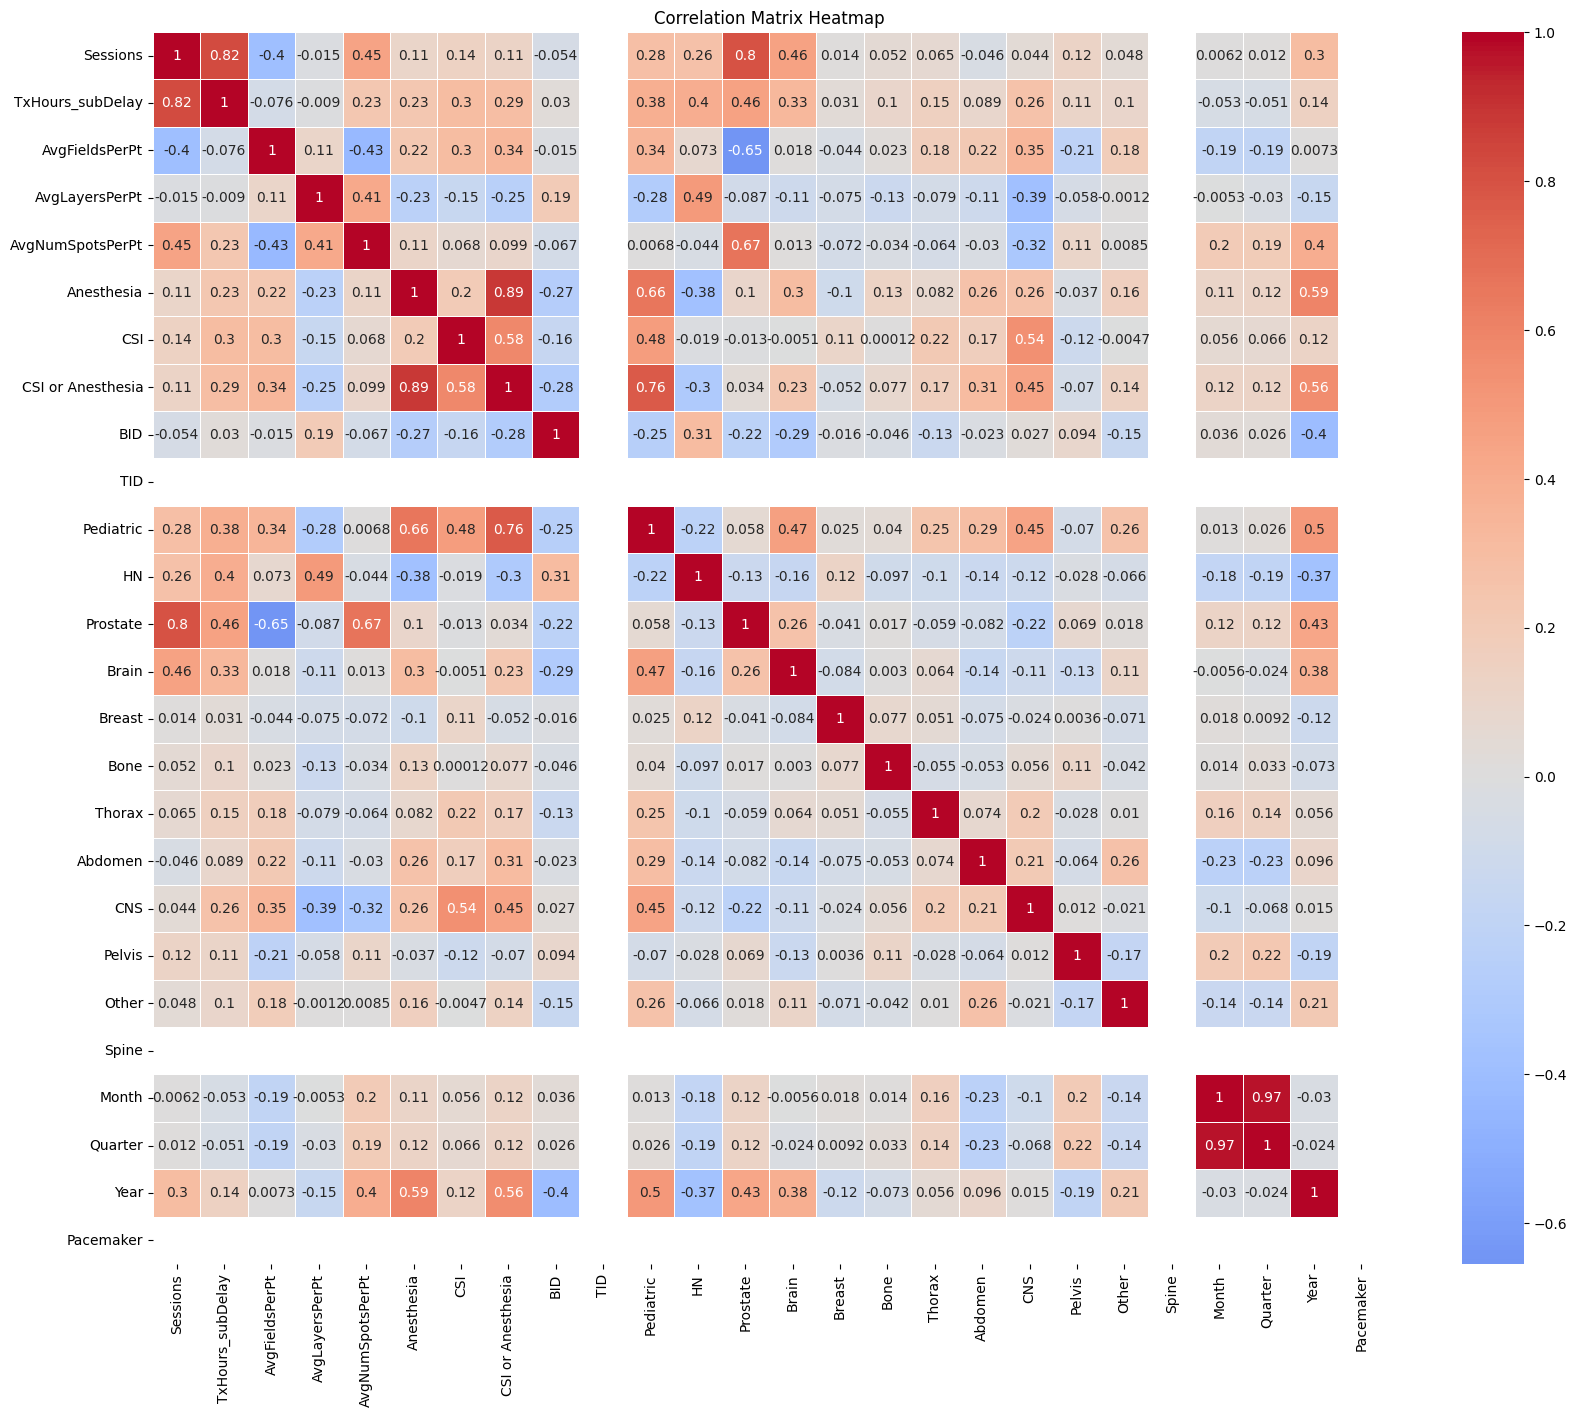

In [5]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [8]:
# 10 variables with highest correlation to hours:
df_proton.corr()["TxHours_subDelay"] \
  .drop("TxHours_subDelay") \
  .abs() \
  .sort_values(ascending=False) \
  .head(10)


Sessions             0.820024
Prostate             0.455670
HN                   0.397943
Pediatric            0.381482
Brain                0.333499
CSI                  0.296302
CSI or Anesthesia    0.293698
CNS                  0.261547
Anesthesia           0.230346
AvgNumSpotsPerPt     0.225318
Name: TxHours_subDelay, dtype: float64

In [9]:
# Creating New Data Frame with all columns needed for this:

df_model = df_proton[[
    "TxHours_subDelay",                 # treatment hours
    "Sessions",                         # total patients per day
    "Prostate",                         # number of prostate patients
    "Pediatric",                        # number of pediatric patients
    "HN",
    "Brain",
    "CSI",
    "CNS",
    "Anesthesia",
    "AvgNumSpotsPerPt"
]].copy()

df_model["pct_prostate"] = (
    df_model["Prostate"] / df_model["Sessions"]
)

df_model["pct_pediatric"] = (
    df_model["Pediatric"] / df_model["Sessions"]
)

df_model["pct_HN"] = (
    df_model["HN"] / df_model["Sessions"]
)

df_model["pct_Brain"] = (
    df_model["Brain"] / df_model["Sessions"]
)

df_model["pct_CSI"] = (
    df_model["CSI"] / df_model["Sessions"]
)

df_model["pct_CNS"] = (
    df_model["CNS"] / df_model["Sessions"]
)

df_model["pct_Anesthesia"] = (
    df_model["Anesthesia"] / df_model["Sessions"]
)

df_model["pct_AvgNumSpotsPerPt"] = (
    df_model["AvgNumSpotsPerPt"] / df_model["Sessions"]
)

df_model.head(5)

,TxHours_subDelay,Sessions,Prostate,Pediatric,HN,Brain,CSI,CNS,Anesthesia,AvgNumSpotsPerPt,pct_prostate,pct_pediatric,pct_HN,pct_Brain,pct_CSI,pct_CNS,pct_Anesthesia,pct_AvgNumSpotsPerPt
0,8.532933,17,6,3,1,3,0,5,0,2347.009804,0.352941,0.176471,0.058824,0.176471,0.0,0.294118,0.0,138.059400
1,10.699600,21,5,5,3,4,0,6,0,2434.095238,0.238095,0.238095,0.142857,0.190476,0.0,0.285714,0.0,115.909297
2,9.649600,21,5,5,3,4,0,6,0,2280.626984,0.238095,0.238095,0.142857,0.190476,0.0,0.285714,0.0,108.601285
3,8.549600,18,5,5,2,3,0,5,0,2382.629630,0.277778,0.277778,0.111111,0.166667,0.0,0.277778,0.0,132.368313
4,8.166267,17,5,4,2,3,0,4,0,2323.147059,0.294118,0.235294,0.117647,0.176471,0.0,0.235294,0.0,136.655709


## Model 1: ##

$$
\text{Hours}
= \beta_0
+ \beta_1 (\%\text{Prostate})
+ \varepsilon
$$

── Forward Stepwise + Lasso CV Model Comparison ──────────────────────
── Forward Stepwise Feature Entry Order ──────────────────────────
  Added: 'pct_prostate'  CV R²=0.0675

── Lasso CV over each feature subset ─────────────────────────────
    Features  Num Features  Best Alpha (λ) Surviving Features  Num Surviving  CV R² (mean)  CV MSE (mean)  Train R²  Train Adj R²  Test R²  Test Adj R²
pct_prostate             1        0.000596       pct_prostate              1        0.0675         3.9423    0.0832        0.0821   0.0583       0.0539

✔ Best features after Lasso shrinkage : ['pct_prostate']
✔ Best alpha (λ)                      : 0.000596

── Beta Coefficients after Lasso (Best Model) ────────────────────────
     Feature  Beta (β)  Shrunk to 0
pct_prostate    0.5952        False

✔ Y-Intercept (scaled space) : 12.4969
✔ Y-Intercept (original space): 11.3780


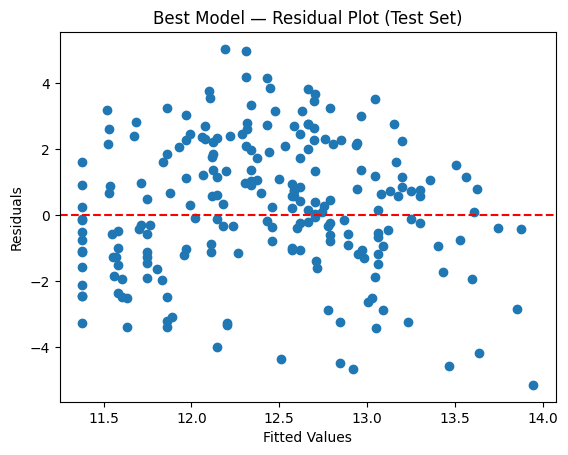

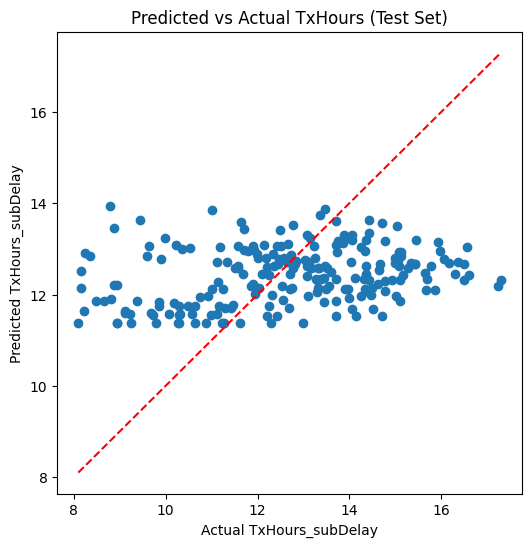

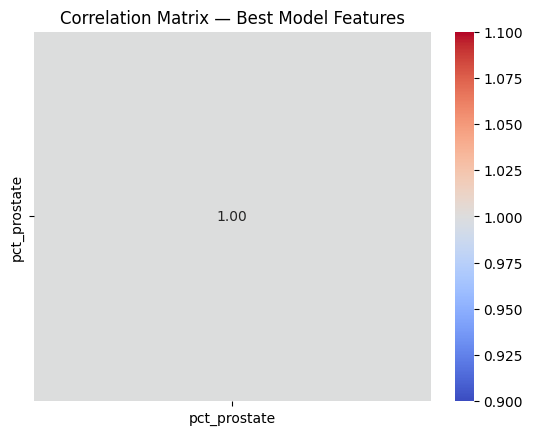


── VIF Table ─────────────────────────────────────────────────────────
     Feature  VIF  High VIF
pct_prostate  1.0     False

MSE (train residuals): 3.9127


In [ ]:
# CV using the pct_prostate like collaborator detailed
# check the best option using cv-cross validation and training and test data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 1. Define features and target ─────────────────────────────────────────────
features = ["pct_prostate"]
target   = "TxHours_subDelay"

y = df_model[target]
X = df_model[["pct_prostate"]]

# ── 2. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, shuffle=True
)

# ── 3. Adjusted R² helper ─────────────────────────────────────────────────────
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


# ── 4. All-subsets comparison table with CV ───────────────────────────────────
# ── 4. Forward stepwise selection with CV + Lasso penalty ─────────────────────
def forward_stepwise_lasso_cv(X_train, X_test, y_train, y_test, features, k_folds=5):
    """
    At each step, adds the feature that most improves CV R².
    Then uses Lasso to penalize features and shrink unimportant betas to zero.
    Alpha (penalty strength) is chosen via CV.
    """
    from sklearn.model_selection import KFold
    from sklearn.linear_model import LassoCV, Lasso
    from sklearn.preprocessing import StandardScaler

    kf        = KFold(n_splits=k_folds, shuffle=True, random_state=100)
    results   = []

    # ── Step 1: Forward stepwise to rank feature entry order ──────────────────
    remaining = features.copy()
    selected  = []

    print("── Forward Stepwise Feature Entry Order ──────────────────────────")
    while remaining:
        best_cv_r2   = -np.inf
        best_feature = None

        for feature in remaining:
            combo = selected + [feature]
            cv_r2_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_cv_tr  = sm.add_constant(X_train[combo].iloc[train_idx])
                X_cv_val = sm.add_constant(
                    X_train[combo].iloc[val_idx], has_constant="add"
                )
                y_cv_tr  = y_train.iloc[train_idx]
                y_cv_val = y_train.iloc[val_idx]

                cv_model  = sm.OLS(y_cv_tr, X_cv_tr).fit()
                y_cv_pred = cv_model.predict(X_cv_val)
                cv_r2_scores.append(r2_score(y_cv_val, y_cv_pred))

            if np.mean(cv_r2_scores) > best_cv_r2:
                best_cv_r2   = np.mean(cv_r2_scores)
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)
        print(f"  Added: '{best_feature}'  CV R²={best_cv_r2:.4f}")

    # ── Step 2: For each subset size, apply Lasso + CV alpha selection ─────────
    print("\n── Lasso CV over each feature subset ─────────────────────────────")
    for k in range(1, len(selected) + 1):
        combo  = selected[:k]
        scaler = StandardScaler()

        X_tr_raw = X_train[combo].values
        X_te_raw = X_test[combo].values
        y_tr     = y_train.values
        y_te     = y_test.values

        # Scale for Lasso (required for fair penalization)
        X_tr_scaled = scaler.fit_transform(X_tr_raw)
        X_te_scaled = scaler.transform(X_te_raw)

        # LassoCV finds the best alpha via k-fold CV automatically
        lasso_cv = LassoCV(cv=kf, random_state=100, max_iter=10000)
        lasso_cv.fit(X_tr_scaled, y_tr)
        best_alpha = lasso_cv.alpha_

        # Refit with best alpha
        lasso = Lasso(alpha=best_alpha, max_iter=10000)
        lasso.fit(X_tr_scaled, y_tr)

        y_pred_train = lasso.predict(X_tr_scaled)
        y_pred_test  = lasso.predict(X_te_scaled)

        r2_train     = r2_score(y_tr, y_pred_train)
        adj_r2_train = adjusted_r2(r2_train, len(y_tr), k)
        r2_test      = r2_score(y_te, y_pred_test)
        adj_r2_test  = adjusted_r2(r2_test, len(y_te), k)

        # CV R² on train set with best alpha
        cv_r2_scores  = []
        cv_mse_scores = []
        for train_idx, val_idx in kf.split(X_tr_scaled):
            lasso_fold = Lasso(alpha=best_alpha, max_iter=10000)
            lasso_fold.fit(X_tr_scaled[train_idx], y_tr[train_idx])
            y_fold_pred = lasso_fold.predict(X_tr_scaled[val_idx])
            cv_r2_scores.append(r2_score(y_tr[val_idx], y_fold_pred))
            cv_mse_scores.append(np.mean((y_tr[val_idx] - y_fold_pred) ** 2))

        # Track which features survived Lasso shrinkage (coef != 0)
        surviving = [f for f, c in zip(combo, lasso.coef_) if c != 0]

        results.append({
            "Features"            : ", ".join(combo),
            "Num Features"        : k,
            "Best Alpha (λ)"      : round(best_alpha, 6),
            "Surviving Features"  : ", ".join(surviving) if surviving else "none",
            "Num Surviving"       : len(surviving),
            "CV R² (mean)"        : round(np.mean(cv_r2_scores), 4),
            "CV MSE (mean)"       : round(np.mean(cv_mse_scores), 4),
            "Train R²"            : round(r2_train, 4),
            "Train Adj R²"        : round(adj_r2_train, 4),
            "Test R²"             : round(r2_test, 4),
            "Test Adj R²"         : round(adj_r2_test, 4),
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("CV R² (mean)", ascending=False)
        .reset_index(drop=True)
    )
    return results_df


print("── Forward Stepwise + Lasso CV Model Comparison ──────────────────────")
subset_table = forward_stepwise_lasso_cv(X_train, X_test, y_train, y_test, features, k_folds=5)
print(subset_table.to_string(index=False))


# ── 5. Fit best model using surviving Lasso features ──────────────────────────
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

best_row      = subset_table.iloc[0]
best_features = best_row["Surviving Features"].split(", ")
best_alpha    = best_row["Best Alpha (λ)"]
print(f"\n✔ Best features after Lasso shrinkage : {best_features}")
print(f"✔ Best alpha (λ)                      : {best_alpha}")

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train[best_features])
X_test_sc    = scaler.transform(X_test[best_features])     # uses ONLY best_features

best_model   = Lasso(alpha=best_alpha, max_iter=10000)
best_model.fit(X_train_sc, y_train)

y_pred_train = best_model.predict(X_train_sc)
y_pred_test  = best_model.predict(X_test_sc)               # uses ONLY X_test_sc

# ── Beta coefficients table ───────────────────────────────────────────────────
beta_df = pd.DataFrame({
    "Feature"    : best_features,
    "Beta (β)"   : best_model.coef_.round(4),
    "Shrunk to 0": best_model.coef_ == 0
})
print("\n── Beta Coefficients after Lasso (Best Model) ────────────────────────")
print(beta_df.to_string(index=False))
# ── Intercept (y-intercept) ───────────────────────────────────────────────────
print(f"\n✔ Y-Intercept (scaled space) : {best_model.intercept_:.4f}")

# To get intercept in original (unscaled) space
intercept_original = best_model.intercept_ - np.dot(
    best_model.coef_, scaler.mean_ / scaler.scale_
)
print(f"✔ Y-Intercept (original space): {intercept_original:.4f}")

# ── 6. Residual plot (test set) ───────────────────────────────────────────────
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.title("Best Model — Residual Plot (Test Set)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.axhline(0, color="red", linestyle="--")
plt.show()


# ── 7. Predicted vs Actual (test set) ─────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.title("Predicted vs Actual TxHours (Test Set)")
plt.xlabel("Actual TxHours_subDelay")
plt.ylabel("Predicted TxHours_subDelay")
plt.show()


# ── 8. Correlation heatmap ────────────────────────────────────────────────────
correlation_matrix = X_train[best_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Best Model Features")
plt.show()


# ── 9. VIF (train set, best model) ───────────────────────────────────────────
X_vif    = sm.add_constant(X_train[best_features])
vif_data = pd.DataFrame({
    "Feature"  : X_vif.columns[1:],
    "VIF"      : [variance_inflation_factor(X_vif.values, i)
                  for i in range(1, X_vif.shape[1])]
})
vif_data["High VIF"] = vif_data["VIF"] > 5
print("\n── VIF Table ─────────────────────────────────────────────────────────")
print(vif_data.to_string(index=False))

# CORRECT
mse_train = np.mean((y_train.values - y_pred_train) ** 2)
print("\nMSE (train residuals):", round(mse_train, 4))

- strange that as number of prostate cancer patients increases, the number of hours decreases
- this contradicts the original abstract

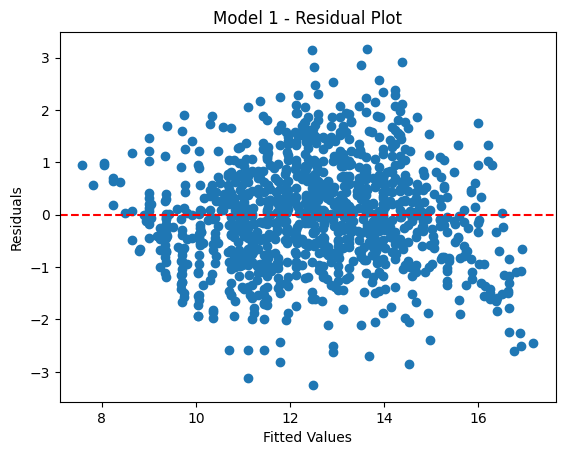

In [11]:
#Making the residual plots
# Checking against the linear assumptions

y_predictions = model1.predict(X)
residuals = y - y_predictions

plt.scatter(y_predictions, residuals)
plt.title("Model 1 - Residual Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.axhline(np.mean(residuals), color="red", linestyle="--")
plt.show()

$$
\text{Hours} = 4.0962 
+ 1.0683(\text{Prostate}) 
- 0.1100(\text{Pediatric}) 
+ 1.3633(\text{HN}) 
+ 0.7131(\text{Brain}) 
+ 0.7445(\text{CNS})
+ 0.1313(\text{CSI})
+ 0.4060(\text{Anesthesia})
\\
+ 0.2976(\text{Thorax})
+ 0.3151(\text{Pelvis})
+ 0.2302(\text{Bone})
+ 0.3106(\text{Abdomen})
$$

── Forward Stepwise + Lasso CV Model Comparison ──────────────────────
── Forward Stepwise Feature Entry Order ──────────────────────────
  Added: 'Prostate'  CV R²=0.2057
  Added: 'HN'  CV R²=0.3994
  Added: 'Pediatric'  CV R²=0.6235
  Added: 'CNS'  CV R²=0.6871
  Added: 'Brain'  CV R²=0.7232
  Added: 'Anesthesia'  CV R²=0.7429
  Added: 'Pelvis'  CV R²=0.7622
  Added: 'Thorax'  CV R²=0.7799
  Added: 'Abdomen'  CV R²=0.7972
  Added: 'Bone'  CV R²=0.8095
  Added: 'CSI'  CV R²=0.8109
  Added: 'Spine'  CV R²=0.8109
  Added: 'Breast'  CV R²=0.8108

── Lasso CV over each feature subset ─────────────────────────────
                                                                                          Features  Num Features  Best Alpha (λ)                                                                          Surviving Features  Num Surviving  CV R² (mean)  CV MSE (mean)  Train R²  Train Adj R²  Test R²  Test Adj R²
        Prostate, HN, Pediatric, CNS, Brain, Anesthesia, Pelvis, Thorax

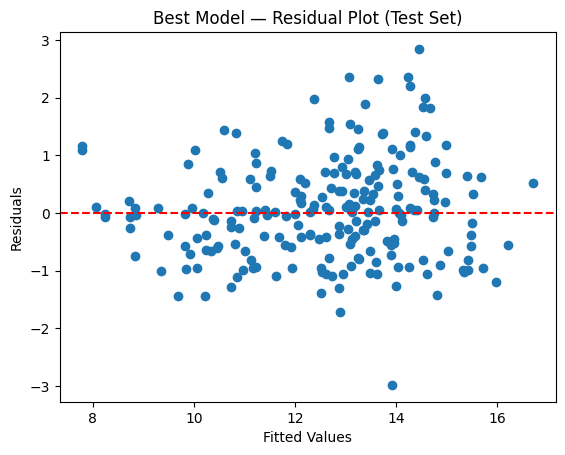

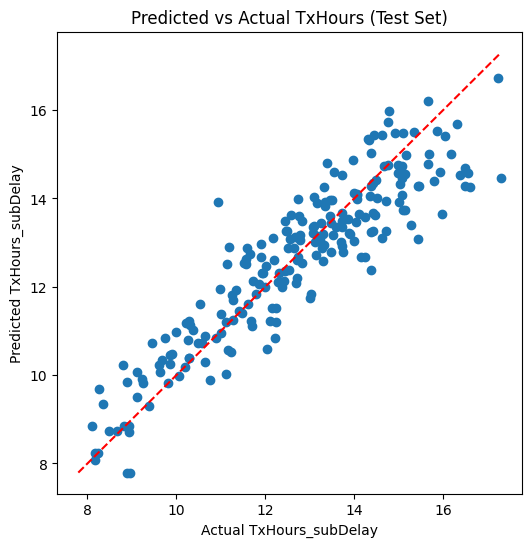

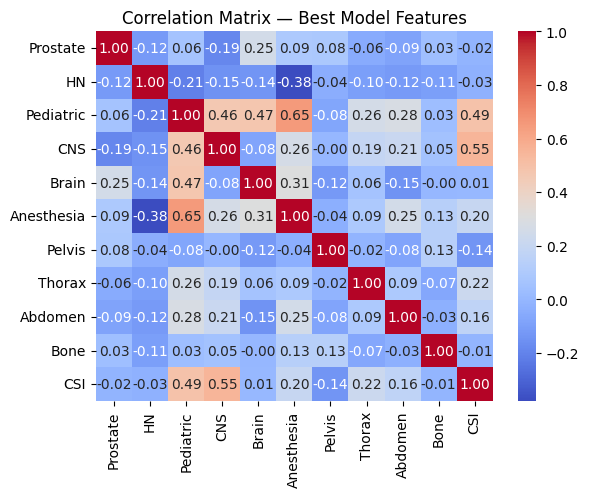


── VIF Table ─────────────────────────────────────────────────────────
   Feature      VIF  High VIF
  Prostate 1.157444     False
        HN 1.230797     False
 Pediatric 3.625860     False
       CNS 1.807824     False
     Brain 1.866740     False
Anesthesia 2.078164     False
    Pelvis 1.095668     False
    Thorax 1.114187     False
   Abdomen 1.265034     False
      Bone 1.056394     False
       CSI 1.788707     False

MSE (train residuals): 0.7702


In [ ]:
# check the best option using cross validation and training and testing data. This model has all features except sessions. Uses Lasso

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 1. Define features and target ─────────────────────────────────────────────
features = ["Prostate", "Pediatric", "HN", "Brain", "CNS", "CSI", "Anesthesia", "Thorax", "Pelvis", "Bone", "Breast", "Abdomen", "Spine"]
target   = "TxHours_subDelay"

y = df_model[target]
X = df_proton[features]

# ── 2. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, shuffle=True
)

# ── 3. Adjusted R² helper ─────────────────────────────────────────────────────
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


# ── 4. All-subsets comparison table with CV ───────────────────────────────────
# ── 4. Forward stepwise selection with CV + Lasso penalty ─────────────────────
def forward_stepwise_lasso_cv(X_train, X_test, y_train, y_test, features, k_folds=5):
    """
    At each step, adds the feature that most improves CV R².
    Then uses Lasso to penalize features and shrink unimportant betas to zero.
    Alpha (penalty strength) is chosen via CV.
    """
    from sklearn.model_selection import KFold
    from sklearn.linear_model import LassoCV, Lasso
    from sklearn.preprocessing import StandardScaler

    kf        = KFold(n_splits=k_folds, shuffle=True, random_state=100)
    results   = []

    # ── Step 1: Forward stepwise to rank feature entry order ──────────────────
    remaining = features.copy()
    selected  = []

    print("── Forward Stepwise Feature Entry Order ──────────────────────────")
    while remaining:
        best_cv_r2   = -np.inf
        best_feature = None

        for feature in remaining:
            combo = selected + [feature]
            cv_r2_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_cv_tr  = sm.add_constant(X_train[combo].iloc[train_idx])
                X_cv_val = sm.add_constant(
                    X_train[combo].iloc[val_idx], has_constant="add"
                )
                y_cv_tr  = y_train.iloc[train_idx]
                y_cv_val = y_train.iloc[val_idx]

                cv_model  = sm.OLS(y_cv_tr, X_cv_tr).fit()
                y_cv_pred = cv_model.predict(X_cv_val)
                cv_r2_scores.append(r2_score(y_cv_val, y_cv_pred))

            if np.mean(cv_r2_scores) > best_cv_r2:
                best_cv_r2   = np.mean(cv_r2_scores)
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)
        print(f"  Added: '{best_feature}'  CV R²={best_cv_r2:.4f}")

    # ── Step 2: For each subset size, apply Lasso + CV alpha selection ─────────
    print("\n── Lasso CV over each feature subset ─────────────────────────────")
    for k in range(1, len(selected) + 1):
        combo  = selected[:k]
        scaler = StandardScaler()

        X_tr_raw = X_train[combo].values
        X_te_raw = X_test[combo].values
        y_tr     = y_train.values
        y_te     = y_test.values

        # Scale for Lasso (required for fair penalization)
        X_tr_scaled = scaler.fit_transform(X_tr_raw)
        X_te_scaled = scaler.transform(X_te_raw)

        # LassoCV finds the best alpha via k-fold CV automatically
        lasso_cv = LassoCV(cv=kf, random_state=100, max_iter=10000)
        lasso_cv.fit(X_tr_scaled, y_tr)
        best_alpha = lasso_cv.alpha_

        # Refit with best alpha
        lasso = Lasso(alpha=best_alpha, max_iter=10000)
        lasso.fit(X_tr_scaled, y_tr)

        y_pred_train = lasso.predict(X_tr_scaled)
        y_pred_test  = lasso.predict(X_te_scaled)

        r2_train     = r2_score(y_tr, y_pred_train)
        adj_r2_train = adjusted_r2(r2_train, len(y_tr), k)
        r2_test      = r2_score(y_te, y_pred_test)
        adj_r2_test  = adjusted_r2(r2_test, len(y_te), k)

        # CV R² on train set with best alpha
        cv_r2_scores  = []
        cv_mse_scores = []
        for train_idx, val_idx in kf.split(X_tr_scaled):
            lasso_fold = Lasso(alpha=best_alpha, max_iter=10000)
            lasso_fold.fit(X_tr_scaled[train_idx], y_tr[train_idx])
            y_fold_pred = lasso_fold.predict(X_tr_scaled[val_idx])
            cv_r2_scores.append(r2_score(y_tr[val_idx], y_fold_pred))
            cv_mse_scores.append(np.mean((y_tr[val_idx] - y_fold_pred) ** 2))

        # Track which features survived Lasso shrinkage (coef != 0)
        surviving = [f for f, c in zip(combo, lasso.coef_) if c != 0]

        results.append({
            "Features"            : ", ".join(combo),
            "Num Features"        : k,
            "Best Alpha (λ)"      : round(best_alpha, 6),
            "Surviving Features"  : ", ".join(surviving) if surviving else "none",
            "Num Surviving"       : len(surviving),
            "CV R² (mean)"        : round(np.mean(cv_r2_scores), 4),
            "CV MSE (mean)"       : round(np.mean(cv_mse_scores), 4),
            "Train R²"            : round(r2_train, 4),
            "Train Adj R²"        : round(adj_r2_train, 4),
            "Test R²"             : round(r2_test, 4),
            "Test Adj R²"         : round(adj_r2_test, 4),
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("CV R² (mean)", ascending=False)
        .reset_index(drop=True)
    )
    return results_df


print("── Forward Stepwise + Lasso CV Model Comparison ──────────────────────")
subset_table = forward_stepwise_lasso_cv(X_train, X_test, y_train, y_test, features, k_folds=5)
print(subset_table.to_string(index=False))


# ── 5. Fit best model using surviving Lasso features ──────────────────────────
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

best_row      = subset_table.iloc[0]
best_features = best_row["Surviving Features"].split(", ")
best_alpha    = best_row["Best Alpha (λ)"]
print(f"\n✔ Best features after Lasso shrinkage : {best_features}")
print(f"✔ Best alpha (λ)                      : {best_alpha}")

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train[best_features])
X_test_sc    = scaler.transform(X_test[best_features])     # uses ONLY best_features

best_model   = Lasso(alpha=best_alpha, max_iter=10000)
best_model.fit(X_train_sc, y_train)

y_pred_train = best_model.predict(X_train_sc)
y_pred_test  = best_model.predict(X_test_sc)               # uses ONLY X_test_sc

# ── Beta coefficients table ───────────────────────────────────────────────────
beta_df = pd.DataFrame({
    "Feature"    : best_features,
    "Beta (β)"   : best_model.coef_.round(4),
    "Shrunk to 0": best_model.coef_ == 0
})
print("\n── Beta Coefficients after Lasso (Best Model) ────────────────────────")
print(beta_df.to_string(index=False))


# ── 6. Residual plot (test set) ───────────────────────────────────────────────
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.title("Best Model — Residual Plot (Test Set)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.axhline(0, color="red", linestyle="--")
plt.show()


# ── 7. Predicted vs Actual (test set) ─────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.title("Predicted vs Actual TxHours (Test Set)")
plt.xlabel("Actual TxHours_subDelay")
plt.ylabel("Predicted TxHours_subDelay")
plt.show()


# ── 8. Correlation heatmap ────────────────────────────────────────────────────
correlation_matrix = X_train[best_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Best Model Features")
plt.show()


# ── 9. VIF (train set, best model) ───────────────────────────────────────────
X_vif    = sm.add_constant(X_train[best_features])
vif_data = pd.DataFrame({
    "Feature"  : X_vif.columns[1:],
    "VIF"      : [variance_inflation_factor(X_vif.values, i)
                  for i in range(1, X_vif.shape[1])]
})
vif_data["High VIF"] = vif_data["VIF"] > 5
print("\n── VIF Table ─────────────────────────────────────────────────────────")
print(vif_data.to_string(index=False))

# CORRECT
mse_train = np.mean((y_train.values - y_pred_train) ** 2)
print("\nMSE (train residuals):", round(mse_train, 4))

$$
\text{Hours} = \beta_0 
+ \beta_1(\text{Prostate})  
+ \beta_2(\text{HN}) 
+ \beta_3(\text{Brain}) 
+ \beta_4(\text{CNS})
+ \beta_5(\text{Thorax})
+ \beta_6(\text{Pelvis})
+ \beta_7(\text{Bone})
+ \beta_8(\text{Abdomen})
+ \varepsilon
$$

── Forward Stepwise + Lasso CV Model Comparison ──────────────────────
── Forward Stepwise Feature Entry Order ──────────────────────────
  Added: 'Prostate'  CV R²=0.2057
  Added: 'HN'  CV R²=0.3994
  Added: 'CNS'  CV R²=0.5963
  Added: 'Brain'  CV R²=0.7021
  Added: 'Abdomen'  CV R²=0.7302
  Added: 'Pelvis'  CV R²=0.7545
  Added: 'Thorax'  CV R²=0.7713
  Added: 'Bone'  CV R²=0.7874
  Added: 'Spine'  CV R²=0.7874
  Added: 'Breast'  CV R²=0.7874

── Lasso CV over each feature subset ─────────────────────────────
                                                              Features  Num Features  Best Alpha (λ)                                              Surviving Features  Num Surviving  CV R² (mean)  CV MSE (mean)  Train R²  Train Adj R²  Test R²  Test Adj R²
Prostate, HN, CNS, Brain, Abdomen, Pelvis, Thorax, Bone, Spine, Breast            10        0.001035 Prostate, HN, CNS, Brain, Abdomen, Pelvis, Thorax, Bone, Breast              9        0.7874         0.8942    0.7958        0

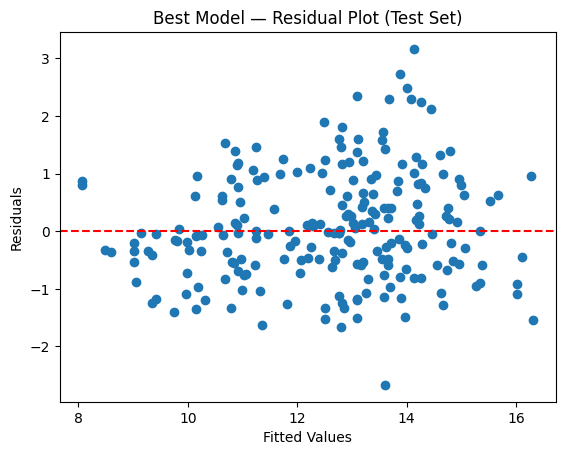

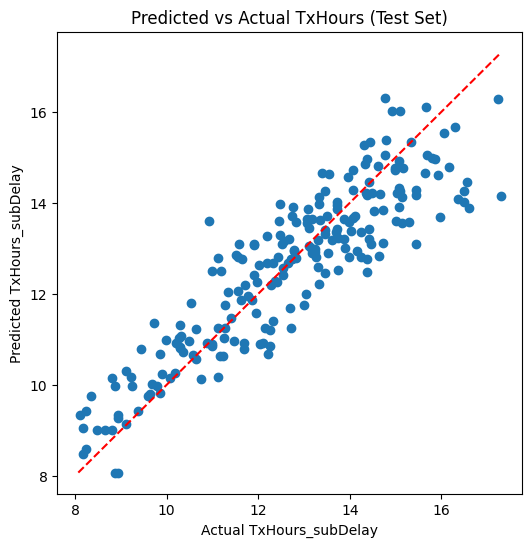

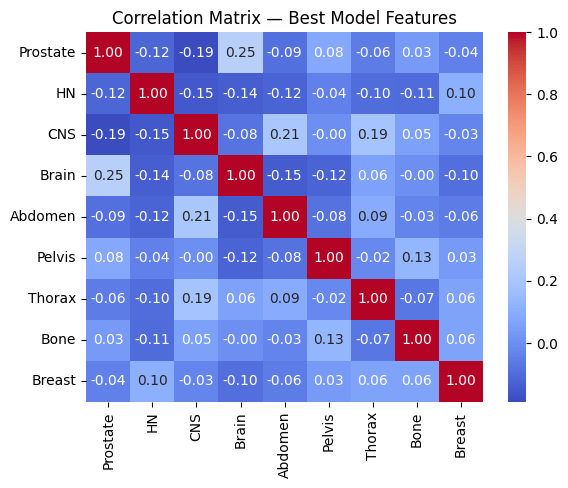


── VIF Table ─────────────────────────────────────────────────────────
 Feature      VIF  High VIF
Prostate 1.135993     False
      HN 1.106975     False
     CNS 1.143230     False
   Brain 1.155809     False
 Abdomen 1.100212     False
  Pelvis 1.060376     False
  Thorax 1.071394     False
    Bone 1.046576     False
  Breast 1.037306     False

MSE (train residuals): 0.8713


In [24]:
# Removed the clinical parameters
# check the best option using cv-cross validation and training and test data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 1. Define features and target ─────────────────────────────────────────────
features = ["Prostate", "HN", "Brain", "CNS", "Thorax", "Pelvis", "Bone", "Breast", "Abdomen", "Spine"]
target   = "TxHours_subDelay"

y = df_model[target]
X = df_proton[features]

# ── 2. Train/test split ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, shuffle=True
)

# ── 3. Adjusted R² helper ─────────────────────────────────────────────────────
def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)


# ── 4. All-subsets comparison table with CV ───────────────────────────────────
# ── 4. Forward stepwise selection with CV + Lasso penalty ─────────────────────
def forward_stepwise_lasso_cv(X_train, X_test, y_train, y_test, features, k_folds=5):
    """
    At each step, adds the feature that most improves CV R².
    Then uses Lasso to penalize features and shrink unimportant betas to zero.
    Alpha (penalty strength) is chosen via CV.
    """
    from sklearn.model_selection import KFold
    from sklearn.linear_model import LassoCV, Lasso
    from sklearn.preprocessing import StandardScaler

    kf        = KFold(n_splits=k_folds, shuffle=True, random_state=100)
    results   = []

    # ── Step 1: Forward stepwise to rank feature entry order ──────────────────
    remaining = features.copy()
    selected  = []

    print("── Forward Stepwise Feature Entry Order ──────────────────────────")
    while remaining:
        best_cv_r2   = -np.inf
        best_feature = None

        for feature in remaining:
            combo = selected + [feature]
            cv_r2_scores = []

            for train_idx, val_idx in kf.split(X_train):
                X_cv_tr  = sm.add_constant(X_train[combo].iloc[train_idx])
                X_cv_val = sm.add_constant(
                    X_train[combo].iloc[val_idx], has_constant="add"
                )
                y_cv_tr  = y_train.iloc[train_idx]
                y_cv_val = y_train.iloc[val_idx]

                cv_model  = sm.OLS(y_cv_tr, X_cv_tr).fit()
                y_cv_pred = cv_model.predict(X_cv_val)
                cv_r2_scores.append(r2_score(y_cv_val, y_cv_pred))

            if np.mean(cv_r2_scores) > best_cv_r2:
                best_cv_r2   = np.mean(cv_r2_scores)
                best_feature = feature

        selected.append(best_feature)
        remaining.remove(best_feature)
        print(f"  Added: '{best_feature}'  CV R²={best_cv_r2:.4f}")

    # ── Step 2: For each subset size, apply Lasso + CV alpha selection ─────────
    print("\n── Lasso CV over each feature subset ─────────────────────────────")
    for k in range(1, len(selected) + 1):
        combo  = selected[:k]
        scaler = StandardScaler()

        X_tr_raw = X_train[combo].values
        X_te_raw = X_test[combo].values
        y_tr     = y_train.values
        y_te     = y_test.values

        # Scale for Lasso (required for fair penalization)
        X_tr_scaled = scaler.fit_transform(X_tr_raw)
        X_te_scaled = scaler.transform(X_te_raw)

        # LassoCV finds the best alpha via k-fold CV automatically
        lasso_cv = LassoCV(cv=kf, random_state=100, max_iter=10000)
        lasso_cv.fit(X_tr_scaled, y_tr)
        best_alpha = lasso_cv.alpha_

        # Refit with best alpha
        lasso = Lasso(alpha=best_alpha, max_iter=10000)
        lasso.fit(X_tr_scaled, y_tr)

        y_pred_train = lasso.predict(X_tr_scaled)
        y_pred_test  = lasso.predict(X_te_scaled)

        r2_train     = r2_score(y_tr, y_pred_train)
        adj_r2_train = adjusted_r2(r2_train, len(y_tr), k)
        r2_test      = r2_score(y_te, y_pred_test)
        adj_r2_test  = adjusted_r2(r2_test, len(y_te), k)

        # CV R² on train set with best alpha
        cv_r2_scores  = []
        cv_mse_scores = []
        for train_idx, val_idx in kf.split(X_tr_scaled):
            lasso_fold = Lasso(alpha=best_alpha, max_iter=10000)
            lasso_fold.fit(X_tr_scaled[train_idx], y_tr[train_idx])
            y_fold_pred = lasso_fold.predict(X_tr_scaled[val_idx])
            cv_r2_scores.append(r2_score(y_tr[val_idx], y_fold_pred))
            cv_mse_scores.append(np.mean((y_tr[val_idx] - y_fold_pred) ** 2))

        # Track which features survived Lasso shrinkage (coef != 0)
        surviving = [f for f, c in zip(combo, lasso.coef_) if c != 0]

        results.append({
            "Features"            : ", ".join(combo),
            "Num Features"        : k,
            "Best Alpha (λ)"      : round(best_alpha, 6),
            "Surviving Features"  : ", ".join(surviving) if surviving else "none",
            "Num Surviving"       : len(surviving),
            "CV R² (mean)"        : round(np.mean(cv_r2_scores), 4),
            "CV MSE (mean)"       : round(np.mean(cv_mse_scores), 4),
            "Train R²"            : round(r2_train, 4),
            "Train Adj R²"        : round(adj_r2_train, 4),
            "Test R²"             : round(r2_test, 4),
            "Test Adj R²"         : round(adj_r2_test, 4),
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("CV R² (mean)", ascending=False)
        .reset_index(drop=True)
    )
    return results_df


print("── Forward Stepwise + Lasso CV Model Comparison ──────────────────────")
subset_table = forward_stepwise_lasso_cv(X_train, X_test, y_train, y_test, features, k_folds=5)
print(subset_table.to_string(index=False))


# ── 5. Fit best model using surviving Lasso features ──────────────────────────
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

best_row      = subset_table.iloc[0]
best_features = best_row["Surviving Features"].split(", ")
best_alpha    = best_row["Best Alpha (λ)"]
print(f"\n✔ Best features after Lasso shrinkage : {best_features}")
print(f"✔ Best alpha (λ)                      : {best_alpha}")

scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train[best_features])
X_test_sc    = scaler.transform(X_test[best_features])     # uses ONLY best_features

best_model   = Lasso(alpha=best_alpha, max_iter=10000)
best_model.fit(X_train_sc, y_train)

y_pred_train = best_model.predict(X_train_sc)
y_pred_test  = best_model.predict(X_test_sc)               # uses ONLY X_test_sc

# ── Beta coefficients table ───────────────────────────────────────────────────
beta_df = pd.DataFrame({
    "Feature"    : best_features,
    "Beta (β)"   : best_model.coef_.round(4),
    "Shrunk to 0": best_model.coef_ == 0
})
print("\n── Beta Coefficients after Lasso (Best Model) ────────────────────────")
print(beta_df.to_string(index=False))


# ── 6. Residual plot (test set) ───────────────────────────────────────────────
residuals = y_test - y_pred_test

plt.scatter(y_pred_test, residuals)
plt.title("Best Model — Residual Plot (Test Set)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.axhline(0, color="red", linestyle="--")
plt.show()


# ── 7. Predicted vs Actual (test set) ─────────────────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.title("Predicted vs Actual TxHours (Test Set)")
plt.xlabel("Actual TxHours_subDelay")
plt.ylabel("Predicted TxHours_subDelay")
plt.show()


# ── 8. Correlation heatmap ────────────────────────────────────────────────────
correlation_matrix = X_train[best_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix — Best Model Features")
plt.show()


# ── 9. VIF (train set, best model) ───────────────────────────────────────────
X_vif    = sm.add_constant(X_train[best_features])
vif_data = pd.DataFrame({
    "Feature"  : X_vif.columns[1:],
    "VIF"      : [variance_inflation_factor(X_vif.values, i)
                  for i in range(1, X_vif.shape[1])]
})
vif_data["High VIF"] = vif_data["VIF"] > 5
print("\n── VIF Table ─────────────────────────────────────────────────────────")
print(vif_data.to_string(index=False))

# CORRECT
mse_train = np.mean((y_train.values - y_pred_train) ** 2)
print("\nMSE (train residuals):", round(mse_train, 4))

----------------------------------------------
Exploratory models, not useful
----------------------------------------------

                            OLS Regression Results                            
Dep. Variable:       TxHours_subDelay   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     22.79
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.05e-06
Time:                        15:41:36   Log-Likelihood:                -2333.3
No. Observations:                1090   AIC:                             4671.
Df Residuals:                    1088   BIC:                             4681.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -416.5732     89.881     -4.635      0.0

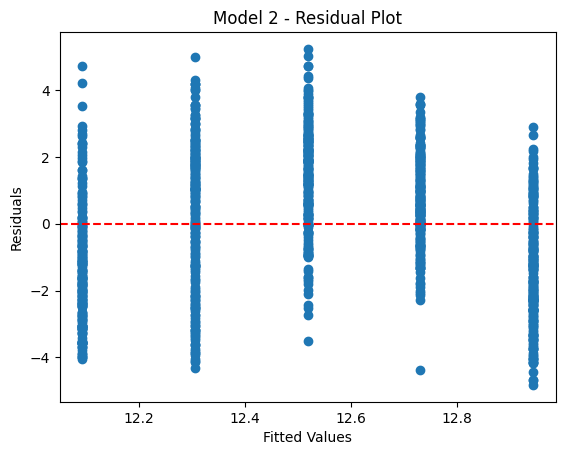

  Feature  VIF  High VIF
0    Year  1.0     False


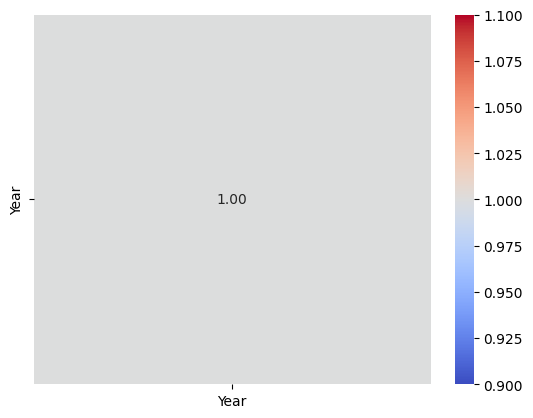

In [28]:
#Predicts the number of hours based on the different type of sessions that make up the day. But the r-squared value is not very
# Define outcome and predictors:
y = df_proton["TxHours_subDelay"]
X = df_proton[["Year"]]

# Add intercept (β0)
X = sm.add_constant(X)

# Fit model
model3 = sm.OLS(y, X, missing="drop").fit()

# View results
print(model3.summary())

#Making the residual plots

y_predictions = model3.predict(X)
residuals = y - y_predictions

plt.scatter(y_predictions, residuals)
plt.title("Model 2 - Residual Plot")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.axhline(np.mean(residuals), color="red", linestyle="--")
plt.show()

# visually checking for multicollinearity
X_no_const = X.drop(columns='const')
correlation_matrix = X_no_const.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# None of the Variables have an VIF value of over 5 --> acceptable 

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns[1:]
vif_data['VIF'] = [variance_inflation_factor(X.values, i) 
                   for i in range(1, X.shape[1])]
vif_data['High VIF'] = vif_data['VIF'] > 5

print(vif_data)


In [29]:
# Loop over each year
for yr in sorted(df_proton["Year"].unique()):
    
    # Subset data for that year
    df_year = df_proton[df_proton["Year"] == yr]
    
    # Define outcome and predictors
    y = df_year["TxHours_subDelay"]
    X = df_year[[
        "Prostate",
        "Pediatric",
        "HN",
        "Brain",
        "CSI",
        "CNS",
        "Anesthesia"
    ]]
    
    # Add intercept
    X = sm.add_constant(X)
    
    # Fit model
    model = sm.OLS(y, X, missing="drop").fit()
    
    # Print results
    print(f"\n===== Year: {yr} =====")
    print(model.summary())


===== Year: 2020 =====
                            OLS Regression Results                            
Dep. Variable:       TxHours_subDelay   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.769
Method:                 Least Squares   F-statistic:                     94.45
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.01e-58
Time:                        15:41:36   Log-Likelihood:                -249.75
No. Observations:                 198   AIC:                             515.5
Df Residuals:                     190   BIC:                             541.8
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.3924      0

In [31]:
print(df_proton.mean())

Sessions               28.115596
TxHours_subDelay       12.531863
AvgFieldsPerPt          2.791637
AvgLayersPerPt         26.351947
AvgNumSpotsPerPt     4859.160605
Anesthesia              3.047706
CSI                     1.322018
CSI or Anesthesia       4.083486
BID                     0.440367
TID                     0.000000
Pediatric               6.966972
HN                      8.363303
Prostate                8.732110
Brain                   5.211927
Breast                  0.040367
Bone                    0.222018
Thorax                  0.371560
Abdomen                 0.313761
CNS                     3.535780
Pelvis                  0.757798
Other                   0.108257
Spine                   0.000000
Month                   6.549541
Quarter                 2.518349
Year                 2022.064220
Pacemaker               0.000000
dtype: float64
